<h1 style = "text-align: center; color:#00498B" >Proyecto: Venta de bienes raíces</h1>
<h4 style = "text-align: center; color:#0E8BD5" >Curso Análisis de Datos</h4>
<h4 style = "text-align: center; color:#0E8BD5" >Universidad Castro Carazo</h4>

<center><img src = "casa.png" width = "90" height= "90"></center>

<h2 style = "text-align: center; color:#00498B" >Análisis del Mercado de Bienes Raíces en EE.UU.</h2>

<p style = "text-align: justify">En el presente análisis, la empresa PK2 busca evaluar la viabilidad de incursionar en el mercado de bienes raíces en los Estados Unidos, a partir del estudio de un conjunto de datos históricos de ventas de propiedades.

Como primer paso dentro del proceso de analítica de datos, se llevará a cabo una fase de preparación y limpieza de la información, con el objetivo de garantizar la calidad, consistencia y confiabilidad de los datos que serán utilizados en el análisis posterior.

Durante esta etapa, se identificarán posibles problemas en el dataset, tales como valores nulos, registros duplicados, inconsistencias en los formatos y errores en la estructura de las variables. Posteriormente, se aplicarán técnicas de limpieza y transformación de datos para corregir dichas anomalías.

El resultado de este proceso será la generación de un dataset depurado y estructurado, el cual servirá como base para el desarrollo de los análisis exploratorios, visualizaciones y generación de insights estratégicos que apoyen la toma de decisiones de la empresa.

Este enfoque permite asegurar que las conclusiones obtenidas estén respaldadas por datos confiables y preparados adecuadamente bajo buenas prácticas de ciencia de datos.</p>

<h2 style = "text-align: center; color:#00498B" >Recursos del proyecto</h2>
<table>
  <tr>
    <td><img src = "informacion.png" width = "32" height= "32"></center></td> 
    <td>Descripción del Dataset PK2</td>
    <td><a href= "https://www.kaggle.com/datasets/utkarshx27/real-estate-sales-2001-2020-gl"> Enlace al sitio web </td>
  </tr>
  <tr> 
    <td><img src = "proceso.png" width = "32" height= "32"></center></td> 
    <td>Especificaciones del proyecto</td>
    <td><a href= "https://github.com/Jzuniga1986/ProyectoDA/blob/main/Proyecto.pdf"> Enlace al sitio web </td>
  </tr>
  <tr> 
    <td><img src = "pantone.png" width = "32" height= "32"></center></td> 
    <td>Paleta de colores del proyecto</td>
    <td><a href= "https://paletadecolores.com.mx/paleta/0e8bd5/0b7bc3/076ab0/045a9e/00498b/"> Enlace al sitio web </td>
</table>

In [1]:
#Parte 1: Mónica Arias

<h2 style = "text-align: justify; color:#0E8BD5" >1. Carga de datos:</h2>

<p style = "text-align: justify">En esta sección se realiza la carga del conjunto de datos que será utilizado para el análisis. El dataset, correspondiente a información de ventas de bienes raíces en Estados Unidos, se encuentra en formato CSV.

Para su manipulación y análisis, se utilizan las bibliotecas Pandas, Seaborn, plotly y Dash de Python, las cuales permiten leer y estructurar los datos en un DataFrame, facilitando su exploración y posterior limpieza.

Una vez cargados los datos, se procede a visualizar una muestra inicial con el fin de comprender su estructura, identificar las variables disponibles y detectar posibles inconsistencias preliminares.</p>

In [2]:
#Imoportar liberias             
import pandas as pd             
import seaborn as sns           
import plotly.express as px
import dash

import warnings
warnings.filterwarnings("ignore")

print ("✅ * Librerias cargadas con exito")

✅ * Librerias cargadas con exito


In [3]:
#Imoportar el dataframe   
df = pd.read_csv("dataSet.csv", sep=";", engine="python")

#Eliminar columnas vacias
df = df.dropna(axis=1, how="all")

#Eliminar columnas "Unnamed"
df = df.loc[:, ~df.columns.str.contains("^Unnamed", case=False)]

#Limpiar nombres de las columnas
df.columns = df.columns.str.strip().str.upper()

print ("✅ * Dataset cargado con exito")
print ("Dimensión del Dataset:", df.shape)

df.head()

✅ * Dataset cargado con exito
Dimensión del Dataset: (190020, 15)


,SERIAL NUMBER,LIST YEAR,DATE RECORDED,TOWN,ADDRESS,ASSESSED VALUE,SALE AMOUNT,SALES RATIO,PROPERTY TYPE,RESIDENTIAL TYPE,NON USE CODE,ASSESSOR REMARKS,OPM REMARKS,LOCATION,",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,"
0,2020348,2020,9/13/2021,Ansonia,230 WAKELEE AVE,150500,325000,0.463,Commercial,NaN,NaN,NaN,NaN,NaN,",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."
1,20002,2020,10/2/2020,Ashford,390 TURNPIKE RD,253000,430000,0.5883,Residential,Single Family,NaN,NaN,NaN,NaN,",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."
2,200212,2020,3/9/2021,Avon,5 CHESTNUT DRIVE,130400,179900,0.7248,Residential,Condo,NaN,NaN,NaN,NaN,",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."
3,200243,2020,4/13/2021,Avon,111 NORTHINGTON DRIVE,619290,890000,0.6958,Residential,Single Family,NaN,NaN,NaN,NaN,",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."
4,200377,2020,7/2/2021,Avon,70 FAR HILLS DRIVE,862330,1447500,0.5957,Residential,Single Family,NaN,NaN,NaN,NaN,",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."


<h4 style = "text-align: justify; color:#0E8BD5" >Minuta de consulta con PK2:</h4>
<p style = "text-align: justify">Durante la fase inicial de carga y exploración del dataset, se identificaron diversos hallazgos relevantes relacionados con la calidad y estructura de los datos.

En primer lugar, se detectó que el archivo original contenía delimitadores inconsistentes, lo que generó una lectura incorrecta de las columnas. Este inconveniente fue corregido mediante la especificación del delimitador adecuado, logrando una correcta estructuración del dataset.

Adicionalmente, se identificó la presencia de múltiples columnas vacías o con un alto porcentaje de valores nulos, así como columnas generadas automáticamente sin contenido relevante (por ejemplo, columnas tipo “Unnamed”). Estas columnas no aportaban valor significativo para el análisis planteado.

Ante esta situación, se procedió a realizar una validación con el cliente, con el fin de confirmar si dichas variables eran necesarias para responder a las preguntas de negocio establecidas. Tras la revisión, se concluyó que estas columnas no eran relevantes para los objetivos del proyecto.

Como resultado, el cliente autorizó la eliminación de dichas variables, permitiendo así optimizar el dataset y enfocarlo únicamente en la información clave para el análisis.

Finalmente, se realizó la estandarización de los nombres de las columnas y la depuración de la estructura del dataset, obteniendo un conjunto de datos limpio, consistente y listo para su análisis.</p>

<h2 style = "text-align: justify; color:#0E8BD5" >2. Limpieza de datos:</h2>

<p style = "text-align: justify">En esta sección se realiza el proceso de limpieza y preparación del dataset, con el objetivo de garantizar la calidad, consistencia y confiabilidad de la información.

Para ello, se analizan aspectos como la presencia de valores nulos, registros duplicados y la correcta tipificación de las variables. Estas acciones permiten asegurar que los datos se encuentren en condiciones óptimas para su análisis posterior.</p>

In [4]:
#Identificar valores nulos
df.isnull().sum()

SERIAL NUMBER                                                                                                                                               12
LIST YEAR                                                                                                                                                   74
DATE RECORDED                                                                                                                                               80
TOWN                                                                                                                                                        77
ADDRESS                                                                                                                                                     86
ASSESSED VALUE                                                                                                                                              84
SALE AMOUNT                                   

In [5]:
#Eliminar las columnas que presentan muchos datos nulos y no se necesitan para responder las BQ
df = df.drop(columns=[
    "NON USE CODE",
    "ASSESSOR REMARKS",
    "OPM REMARKS",
    "LOCATION",
])

print ("✅ * Columnas eliminadas correctamente")

✅ * Columnas eliminadas correctamente


In [6]:
#Asegrar que hayan sido eliminadas
df.columns

Index(['SERIAL NUMBER', 'LIST YEAR', 'DATE RECORDED', 'TOWN', 'ADDRESS',
       'ASSESSED VALUE', 'SALE AMOUNT', 'SALES RATIO', 'PROPERTY TYPE',
       'RESIDENTIAL TYPE',
       ',,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,'],
      dtype='object')

In [7]:
#Identificar columnas "basura"
df.columns.tolist()

['SERIAL NUMBER',
 'LIST YEAR',
 'DATE RECORDED',
 'TOWN',
 'ADDRESS',
 'ASSESSED VALUE',
 'SALE AMOUNT',
 'SALES RATIO',
 'PROPERTY TYPE',
 'RESIDENTIAL TYPE',
 ',,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,']

In [8]:
#Eliminar las columnas "basura"
df.drop(columns=[
    ",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,"
])    

,SERIAL NUMBER,LIST YEAR,DATE RECORDED,TOWN,ADDRESS,ASSESSED VALUE,SALE AMOUNT,SALES RATIO,PROPERTY TYPE,RESIDENTIAL TYPE
0,2020348,2020,9/13/2021,Ansonia,230 WAKELEE AVE,150500,325000,0.463,Commercial,NaN
1,20002,2020,10/2/2020,Ashford,390 TURNPIKE RD,253000,430000,0.5883,Residential,Single Family
2,200212,2020,3/9/2021,Avon,5 CHESTNUT DRIVE,130400,179900,0.7248,Residential,Condo
3,200243,2020,4/13/2021,Avon,111 NORTHINGTON DRIVE,619290,890000,0.6958,Residential,Single Family
4,200377,2020,7/2/2021,Avon,70 FAR HILLS DRIVE,862330,1447500,0.5957,Residential,Single Family
...,...,...,...,...,...,...,...,...,...,...
190015,20763,2002,6/17/2003,West Haven,130 JONES ST,70700,179000,0.394972067,NaN,NaN
190016,21066,2002,7/22/2003,West Hartford,15 PORTER DR,240880,515000,0.467728155,NaN,NaN
190017,30531,2003,4/15/2004,East Hartford,43 TIFFANY RD,80330,130000,0.617923077,NaN,NaN
190018,30624,2003,3/3/2004,Bristol,81 ANDREWS ST,69230,130000,0.532538462,NaN,NaN


In [17]:
#
df.columns = df.columns.str.strip()

df = df.loc[:, ~df.columns.str.contains('^,')]
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.dropna(axis=1, how='all')

df.columns

Index(['SERIAL NUMBER', 'LIST YEAR', 'DATE RECORDED', 'TOWN', 'ADDRESS',
       'ASSESSED VALUE', 'SALE AMOUNT', 'SALES RATIO', 'PROPERTY TYPE',
       'RESIDENTIAL TYPE'],
      dtype='object')

<h4 style = "text-align: justify; color:#0E8BD5" >Minuta de consulta con PK2:</h4>
<p style = "text-align: justify">Durante la integración final del análisis, se identificó la presencia de registros atípicos dentro de la variable “PROPERTY TYPE”, correspondientes a caracteres sin valor analítico.

Estos valores fueron clasificados como inconsistentes, por lo que se procedió a transformarlos en valores nulos y posteriormente se eliminaron del dataset, con el fin de evitar distorsiones en la representación gráfica y en los resultados del análisis.</p>

In [28]:
#Limpiar PROPERTY TYPE más a fondo
df["PROPERTY TYPE"] = df["PROPERTY TYPE"].astype(str).str.strip()

#Reemplazar cualquier valor formado solo por comas, puntos, espacios o comillas
df["PROPERTY TYPE"] = df["PROPERTY TYPE"].replace(
    r'^[,\.\s\'"]+$', pd.NA, regex=True
)

#Reemplazar textos vacíos
df["PROPERTY TYPE"] = df["PROPERTY TYPE"].replace("", pd.NA)

#Eliminar filas sin valor útil
df = df.dropna(subset=["PROPERTY TYPE"])

In [34]:
#Eliminar filas con valores nulos en la variable "PROPERTY TYPE"
df["PROPERTY TYPE"].value_counts(dropna=False)

PROPERTY TYPE
Residential       51271
Vacant Land        2621
Commercial         1713
Apartments          402
Condo               370
Industrial          196
Public Utility        4
Two Family            2
Single Family         2
Three Family          1
Name: count, dtype: int64

In [35]:
#Filtrar solo las columnas válidas
tipos_validos = [
    "Residential",
    "Vacant Land",
    "Commercial",
    "Apartments",
    "Condo",
    "Industrial",
    "Public Utility",
    "Two Family",
    "Single Family",
    "Three Family"
]

df = df[df["PROPERTY TYPE"].isin(tipos_validos)]

<h4 style = "text-align: justify; color:#0E8BD5" >Minuta de consulta con PK2:</h4>
<p style = "text-align: justify">Durante la fase de limpieza del dataset, se realizó un análisis detallado de la calidad de los datos, enfocado en la identificación de valores nulos y variables con bajo aporte al análisis.

En primer lugar, se evaluó la presencia de valores nulos en cada una de las columnas, identificando aquellas con un alto nivel de incompletitud. Se determinó que algunas variables, tales como “NON USE CODE”, “ASSESSOR REMARKS”, “OPM REMARKS” y “LOCATION”, presentaban una proporción significativa de datos faltantes.

Adicionalmente, se detectaron columnas generadas por inconsistencias en la estructura del archivo original, las cuales contenían información no relevante o valores vacíos, conocidas como columnas “basura”.

Ante estos hallazgos, se realizó una consulta con el cliente para validar la pertinencia de dichas variables dentro del análisis. El cliente confirmó que, en caso de no ser necesarias para responder las preguntas de negocio, estas podían ser eliminadas.

En función de lo anterior, se procedió a eliminar las columnas mencionadas, priorizando aquellas variables que aportan valor directo al análisis del mercado inmobiliario.

Como resultado, se obtuvo un dataset más limpio, estructurado y enfocado en la información relevante, facilitando así su uso en las etapas posteriores del proyecto.
</p>

In [18]:
#Identificar valores duplicados
df.duplicated().sum()

np.int64(0)

In [19]:
#Eliminar valores duplicados
df = df.drop_duplicates()

print ("✅ * Valores eliminados con éxito")

✅ * Valores eliminados con éxito


In [20]:
#Verificar nuevamente si aún existen valores duplicados
df.duplicated().sum()

np.int64(0)

<h4 style = "text-align: justify; color:#0E8BD5" >Minuta de consulta con PK2:</h4>
<p style = "text-align: justify">Durante el proceso de limpieza de datos, se realizó la identificación de registros duplicados dentro del dataset, encontrando un total de 11 filas repetidas.

Estos registros fueron eliminados con el objetivo de evitar redundancias y posibles sesgos en el análisis, garantizando así la integridad y calidad de la información utilizada en el proyecto.

Posteriormente, se validó la eliminación de dichos registros, confirmando que el dataset no presenta duplicados.
</p>

In [21]:
#Revisión de tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 190009 entries, 0 to 190019
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   SERIAL NUMBER     190008 non-null  object        
 1   LIST YEAR         189946 non-null  object        
 2   DATE RECORDED     189935 non-null  datetime64[ns]
 3   TOWN              189943 non-null  object        
 4   ADDRESS           189934 non-null  object        
 5   ASSESSED VALUE    189933 non-null  float64       
 6   SALE AMOUNT       189933 non-null  float64       
 7   SALES RATIO       189933 non-null  float64       
 8   PROPERTY TYPE     56583 non-null   object        
 9   RESIDENTIAL TYPE  51647 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 15.9+ MB


In [22]:
#Convertir los datos que aparecen como "object" y deben ser "float"/"datetime64"
df["DATE RECORDED"] = pd.to_datetime(df["DATE RECORDED"], errors = "coerce")
df["SALE AMOUNT"] = pd.to_numeric(df["SALE AMOUNT"], errors = "coerce")
df["ASSESSED VALUE"] = pd.to_numeric(df["ASSESSED VALUE"], errors = "coerce")
df["SALES RATIO"] = pd.to_numeric(df["SALES RATIO"], errors = "coerce")

print ("✅ * Datos ajustados correctamente")

✅ * Datos ajustados correctamente


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 190009 entries, 0 to 190019
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   SERIAL NUMBER     190008 non-null  object        
 1   LIST YEAR         189946 non-null  object        
 2   DATE RECORDED     189935 non-null  datetime64[ns]
 3   TOWN              189943 non-null  object        
 4   ADDRESS           189934 non-null  object        
 5   ASSESSED VALUE    189933 non-null  float64       
 6   SALE AMOUNT       189933 non-null  float64       
 7   SALES RATIO       189933 non-null  float64       
 8   PROPERTY TYPE     56583 non-null   object        
 9   RESIDENTIAL TYPE  51647 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 15.9+ MB


<h4 style = "text-align: justify; color:#0E8BD5" >Minuta de consulta con PK2:</h4>
<p style = "text-align: justify">Como parte final del proceso de limpieza, se realizó la revisión y ajuste de los tipos de datos de las variables del dataset, con el objetivo de asegurar su correcta interpretación y análisis.

Se identificó que algunas columnas se encontraban en formato general (object), por lo que se procedió a convertir aquellas variables clave a sus tipos adecuados. En particular, la variable “DATE RECORDED” fue transformada a formato de fecha (datetime), mientras que las variables numéricas “SALE AMOUNT”, “ASSESSED VALUE” y “SALES RATIO” fueron convertidas a formatos numéricos.

Durante este proceso, se aplicaron métodos de conversión que permiten manejar posibles inconsistencias en los datos, garantizando así la estabilidad del análisis.

Como resultado, se obtuvo un dataset correctamente tipificado, lo cual permite realizar análisis más precisos, generar visualizaciones adecuadas y facilitar la toma de decisiones basada en datos confiables.
</p>

In [ ]:
#Parte 2: Heisel Vindas

<h2 style = "text-align: justify; color:#0E8BD5" >3. BQ1: ¿Cuál es el ingresos anual de las propiedades vendidas?</h2>

<p style = "text-align: justify">En esta sección se analiza el comportamiento de los ingresos y la rentabilidad del mercado inmobiliario con base en los datos proporcionados. El objetivo es identificar tendencias en el tiempo y determinar si el negocio es rentable.
</p>

<h4 style = "text-align: justify; color:#0E8BD5" >Minuta de consulta con PK2:</h4>
<p style = "text-align: justify">Sobre el análisis de ingresos, se utilizó la variable 'SALE AMOUNT', la cual representa el valor de venta de las propiedades. Se agruparon los datos por año ('LIST YEAR') con el fin de observar la evolución de los ingresos a lo largo del tiempo. Los resultados muestran una tendencia creciente en los ingresos, lo que indica un aumento en la actividad del mercado inmobiliario. Esto puede deberse tanto a un mayor volumen de ventas como a un incremento en los precios de las propiedades.

Para el análisis de ganacias y evaluar la rentabilidad, se calculó la ganancia como la diferencia entre el valor de venta ('SALE AMOUNT') y el valor tasado ('ASSESSED VALUE'). Este cálculo permite estimar el margen de ganancia de cada propiedad. En general, se observa que la mayoría de las propiedades se venden por encima de su valor tasado, lo que indica un margen de ganancia positivo.
</p>

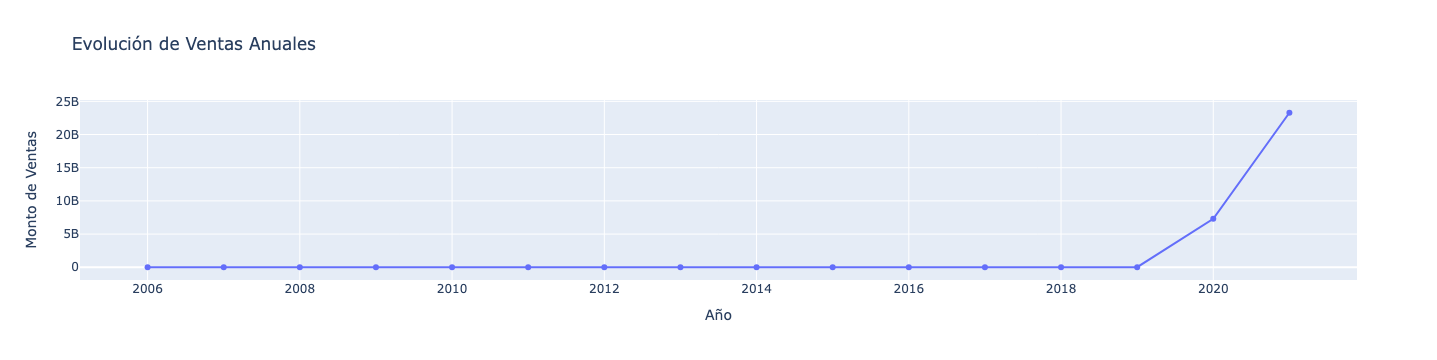

In [36]:
# Convertir datos
df["DATE RECORDED"] = pd.to_datetime(df["DATE RECORDED"], errors="coerce")
df["SALE AMOUNT"] = pd.to_numeric(df["SALE AMOUNT"], errors="coerce")

# Crear año
df["YEAR"] = df["DATE RECORDED"].dt.year

# Limpiar nulos
df = df.dropna(subset=["YEAR", "SALE AMOUNT"])
df = df[df["SALE AMOUNT"] > 0]

# ==============================
# AGRUPAR VENTAS
# ==============================
sales_year = df.groupby("YEAR")["SALE AMOUNT"].sum().reset_index()

# ==============================
# GRÁFICO INTERACTIVO
# ==============================
fig = px.line(
    sales_year,
    x="YEAR",
    y="SALE AMOUNT",
    title="Evolución de Ventas Anuales",
    markers=True
)

fig.update_layout(
    xaxis_title="Año",
    yaxis_title="Monto de Ventas",
    hovermode="x unified"
)

fig.show()

<h4 style = "text-align: justify; color:#0E8BD5" >Minuta de consulta con PK2:</h4>
<p style = "text-align: justify">En conclusión, el análisis evidencia que el mercado inmobiliario presenta una tendencia de crecimiento en los ingresos y mantiene márgenes de ganancia positivos. Esto sugiere que el negocio es rentable. No obstante, es importante considerar que el valor tasado no necesariamente representa el costo real de adquisición, por lo que el margen calculado es una aproximación.
</p>

In [ ]:
#Parte 3: Ashley Solís

<h2 style = "text-align: justify; color:#0E8BD5" >4. BQ2: ¿Qué tipo de propiedad tiene mayor facilidad de venta?</h2>

<p style = "text-align: justify">En esta sección se analizan los tipos de propiedad presentes en el dataset, con el objetivo de identificar cuáles tienen mayor frecuencia de venta y cuáles presentan una mayor rotación en el mercado. Este análisis permite entender la demanda de los diferentes tipos de propiedades y apoyar la toma de decisiones estratégicas.
</p>

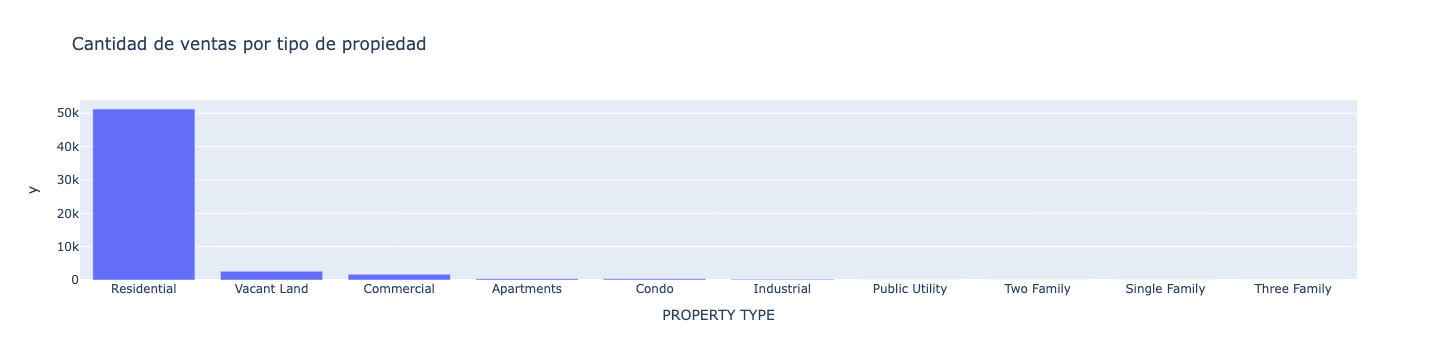

PROPERTY TYPE
Residential       51271
Vacant Land        2621
Commercial         1713
Apartments          402
Condo               370
Industrial          196
Public Utility        4
Single Family         2
Two Family            2
Three Family          1
Name: SALE AMOUNT, dtype: int64

In [32]:
#Conteo de tipos de propiedad
propiedades = df["PROPERTY TYPE"].value_counts()

propiedades

fig = px.bar(
    propiedades,
    x=propiedades.index,
    y=propiedades.values,
    title="Cantidad de ventas por tipo de propiedad"
)

fig.show()

#Agrupar por tipo de propiedad
rotacion = df.groupby("PROPERTY TYPE")["SALE AMOUNT"].count().sort_values(ascending=False)

rotacion

<h4 style = "text-align: justify; color:#0E8BD5" >Minuta de consulta con PK2:</h4>

<p style = "text-align: justify">Se identificó que ciertos tipos de propiedad presentan una mayor cantidad de ventas, lo que indica una mayor demanda dentro del mercado. Asimismo, se observa que estos mismos tipos tienden a rotar más rápidamente, lo que los convierte en opciones más atractivas para inversión.
</p>

In [ ]:
#Parte 4: Sebastián Mora

<h2 style = "text-align: justify; color:#0E8BD5" >5. BQ3: ¿En qué cuidades se concentran las ventas y qué características particulares presentan?</h2>

<p style = "text-align: justify">El análisis de ubicación es una parte fundamental dentro del estudio del mercado inmobiliario, ya que permite comprender cómo se distribuyen las ventas en diferentes zonas geográficas. La ubicación influye directamente en factores como la demanda, el precio y la rentabilidad de las propiedades, siendo un elemento clave en la toma de decisiones estratégicas.
</p>

<h4 style = "text-align: justify; color:#0E8BD5" >Minuta de consulta con PK2:</h4>

<p style = "text-align: justify">El objetivo principal es identificar las ciudades donde se concentra la mayor cantidad de ventas y generación de ingresos, con el fin de detectar oportunidades de inversión y comprender el comportamiento del mercado inmobiliario.

Para el desarrollo de este análisis se utilizó Python junto con la librería pandas, lo que permitió manipular y analizar los datos de forma eficiente. Se trabajó con un dataset que contiene información de propiedades, incluyendo variables como ciudad y precio.
Además, se aplicaron procesos de limpieza de datos, eliminando valores nulos y asegurando que la información fuera consistente y confiable para su análisis.
</p>

In [49]:
df.columns

Index(['Serial Number', 'List Year', 'Date Recorded', 'Town', 'Address',
       'Assessed Value', 'Sale Amount', 'Sales Ratio', 'Property Type',
       'Residential Type',
       ...
       'Unnamed: 129', 'Unnamed: 130', 'Unnamed: 131', 'Unnamed: 132',
       'Unnamed: 133', 'Unnamed: 134', 'Unnamed: 135', 'Unnamed: 136',
       'Unnamed: 137', 'Unnamed: 138'],
      dtype='object', length=139)


VENTAS POR CIUDAD
                                                  Town  Total_Ventas
139                                           Stamford          7846
18                                          Bridgeport          5981
106                                            Norwalk          5868
37                                             Danbury          4471
87                                             Milford          4301
..                                                 ...           ...
2                                          0.723478261             1
3                                     14 - Foreclosure             1
0                                               0.4806             1
112                          POINT (-72.9948 41.57025)             1
144  TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #...             1

[175 rows x 2 columns]

INGRESOS POR CIUDAD
                                                  Town   Sale Amount
60                                     

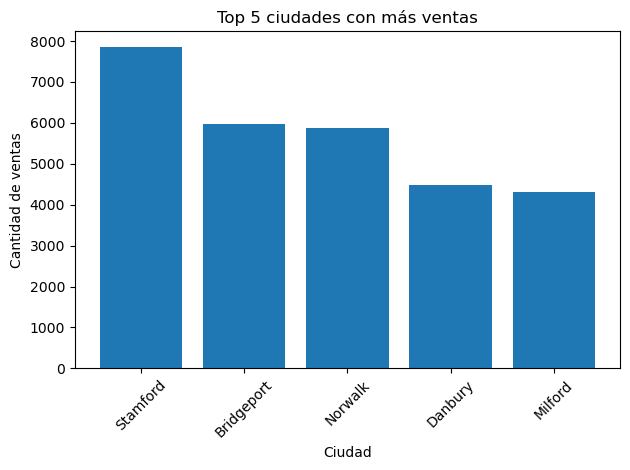

In [51]:
import matplotlib.pyplot as plt

# =========================================
#  ANÁLISIS DE UBICACIÓN
# =========================================

col_ciudad = "Town"
col_precio = "Sale Amount"

#Asegurar que el precio sea numérico
df[col_precio] = pd.to_numeric(df[col_precio], errors="coerce")

#Quitar filas con ciudad o precio nulo
df_ubicacion = df[[col_ciudad, col_precio]].dropna()

#Cantidad de ventas por ciudad
ventas_por_ciudad = df.groupby(col_ciudad).size().reset_index(name="Total_Ventas")
ventas_por_ciudad = ventas_por_ciudad.sort_values(by="Total_Ventas", ascending=False)

#Ingresos por ciudad
ingresos_por_ciudad = df.groupby(col_ciudad)[col_precio].sum().reset_index()
ingresos_por_ciudad = ingresos_por_ciudad.sort_values(by=col_precio, ascending=False)

#Precio promedio por ciudad
precio_promedio = df.groupby(col_ciudad)[col_precio].mean().reset_index()
precio_promedio = precio_promedio.sort_values(by=col_precio, ascending=False)

#Top 5 ciudades con más ventas
top_ventas = ventas_por_ciudad.head(5)

#Top 5 ciudades con más ingresos
top_ingresos = ingresos_por_ciudad.head(5)

# =========================================
#  RESULTADOS EN CONSOLA
# =========================================

print("\n==============================")
print("VENTAS POR CIUDAD")
print("==============================")
print(ventas_por_ciudad)
 
print("\n==============================")
print("INGRESOS POR CIUDAD")
print("==============================")
print(ingresos_por_ciudad)
 
print("\n==============================")
print("PRECIO PROMEDIO POR CIUDAD")
print("==============================")
print(precio_promedio)
 
print("\n==============================")
print("TOP 5 CIUDADES CON MÁS VENTAS")
print("==============================")
print(top_ventas)
 
print("\n==============================")
print("TOP 5 CIUDADES CON MÁS INGRESOS")
print("==============================")
print(top_ingresos)

# =========================================
#  GRÁFICO
# =========================================

plt.figure()
plt.bar(top_ventas[col_ciudad], top_ventas["Total_Ventas"])
plt.title("Top 5 ciudades con más ventas")
plt.xlabel("Ciudad")
plt.ylabel("Cantidad de ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()